In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [2]:
data_protein = pd.read_csv('resultado/04_annotados_protein.groups.tsv', sep='\t', index_col=0)

In [3]:
main_columns = ['CBB_01', 'CBB_02', 'CBB_03','rGlyP_07', 'rGlyP_08','rGlyP_09',]
num_columns = ['CBB_UP_01', 'CBB_UP_02', 'CBB_UP_03', 'rGlyP_UP_07', 'rGlyP_UP_08', 'rGlyP_UP_09']
all_columns = main_columns + num_columns
cepa_CBB = ['CBB_01', 'CBB_02', 'CBB_03']
cepa_rGlyP = ['rGlyP_07', 'rGlyP_08','rGlyP_09']
cepa_CBB_peptido = ['CBB_UP_01', 'CBB_UP_02', 'CBB_UP_03']
cepa_rGlyP_peptido = ['rGlyP_UP_07', 'rGlyP_UP_08', 'rGlyP_UP_09']

In [4]:
data_protein[main_columns]

,CBB_01,CBB_02,CBB_03,rGlyP_07,rGlyP_08,rGlyP_09
Entry,,,,,,
O07451,26.392931,26.320032,26.349343,20.835043,21.201639,19.946541
O30338,21.483608,21.568191,21.640735,21.467156,21.488334,21.483205
O87816,27.211578,27.108774,27.220774,27.499516,27.533413,27.568671
P14611,32.618989,32.412991,32.299652,32.993430,32.812984,32.921867
P14697,27.982094,28.089317,28.277010,28.806529,28.993055,29.002088
...,...,...,...,...,...,...
Q7WXU0,26.380829,26.527723,26.582587,24.817430,24.982458,24.917217
Q83WS0,20.024516,20.853302,19.333546,33.212505,33.180884,33.246544
Q8KLU8,22.928322,22.878103,22.630112,23.168801,23.044661,23.121074


In [5]:
data_protein.columns

Index(['CBB_01', 'CBB_02', 'CBB_03', 'rGlyP_07', 'rGlyP_08', 'rGlyP_09',
       'CBB_UP_01', 'CBB_UP_02', 'CBB_UP_03', 'rGlyP_UP_07', 'rGlyP_UP_08',
       'rGlyP_UP_09', 'CBB_01_imputado', 'CBB_02_imputado', 'CBB_03_imputado',
       'rGlyP_07_imputado', 'rGlyP_08_imputado', 'rGlyP_09_imputado',
       'Entry Name', 'Protein names', 'Gene Names', 'Organism', 'Length',
       'Gene Ontology (biological process)',
       'Gene Ontology (cellular component)', 'Gene Ontology (GO)',
       'Gene Ontology (molecular function)', 'Gene Ontology IDs', 'KEGG'],
      dtype='object')

In [6]:
from sklearn.decomposition import PCA

In [7]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(data_protein[main_columns].to_numpy())

df_pca_coords = pd.DataFrame(
    data = pca_result, 
    columns = ['PC1', 'PC2'],
    index = data_protein.index
)

var_exp = pca.explained_variance_ratio_ * 100

df_pca_coords['Organism'] = data_protein['Organism'].apply(lambda x: x.split('(')[0])
df_pca_coords

,PC1,PC2,Organism
Entry,,,
O07451,-2.864494,-7.242643,Cupriavidus necator
O30338,-7.885686,-0.485743,Cupriavidus necator
O87816,6.391287,0.382703,Cupriavidus necator
P14611,19.414228,0.820279,Cupriavidus necator
P14697,9.238081,1.022943,Cupriavidus necator
...,...,...,...
Q7WXU0,2.392310,-2.088952,Cupriavidus necator
Q83WS0,4.270556,15.998126,Methylorubrum extorquens
Q8KLU8,-4.370872,0.061212,Cupriavidus necator


In [8]:
def plot(col_x, col_y, df, titulo, val_exp=[], hue='Organism', style='Organism', paleta='viridis', file='pca.png'):
    plt.figure(figsize=(10, 8))
    scatter = sns.scatterplot(
        data=df, 
        x=col_x, 
        y=col_y, 
        hue=hue,
        style=style,
        s=120,          
        palette=paleta, 
        alpha=0.8    
    )

    try:
        plt.xlabel(f'PC1 ({var_exp[0]:.2f}%)')
        plt.ylabel(f'PC2 ({var_exp[1]:.2f}%)')
    except NameError:
        plt.xlabel('Componente Principal 1')
        plt.ylabel('Componente Principal 2')

    # 4. Estética adicional
    plt.title(titulo, fontsize=15, pad=20)
    plt.legend(title=hue, bbox_to_anchor=(1.05, 1))
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.savefig(file, dpi=300)
    plt.show()

In [9]:
df_pca_coords

,PC1,PC2,Organism
Entry,,,
O07451,-2.864494,-7.242643,Cupriavidus necator
O30338,-7.885686,-0.485743,Cupriavidus necator
O87816,6.391287,0.382703,Cupriavidus necator
P14611,19.414228,0.820279,Cupriavidus necator
P14697,9.238081,1.022943,Cupriavidus necator
...,...,...,...
Q7WXU0,2.392310,-2.088952,Cupriavidus necator
Q83WS0,4.270556,15.998126,Methylorubrum extorquens
Q8KLU8,-4.370872,0.061212,Cupriavidus necator


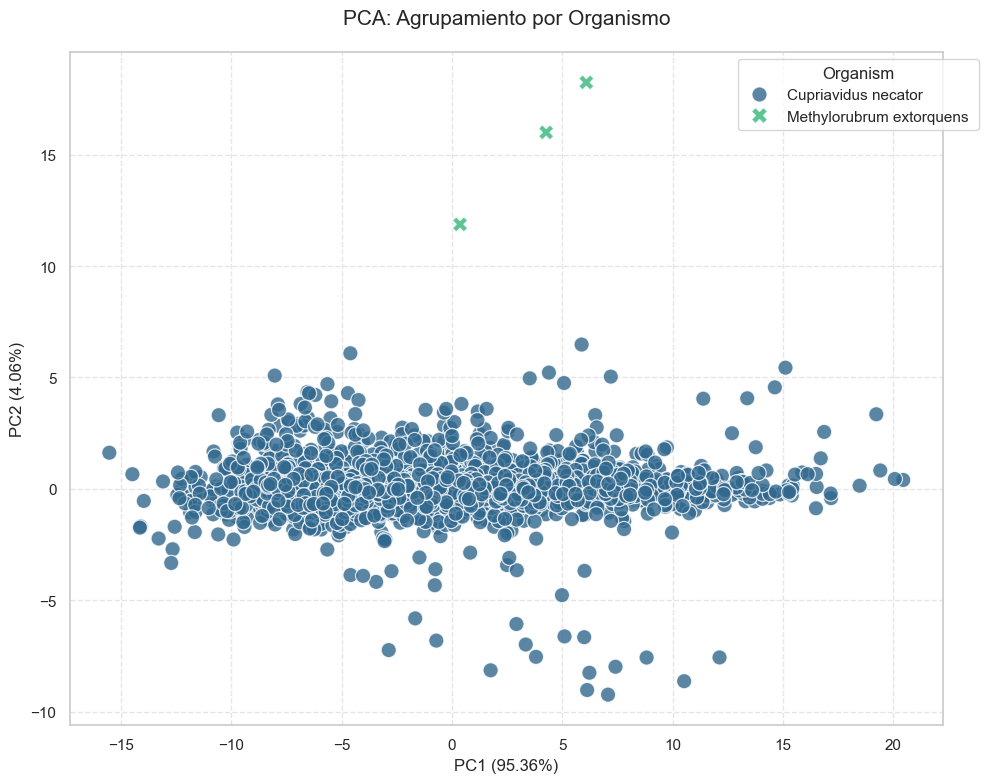

In [10]:
plot('PC1', 'PC2', df_pca_coords, 'PCA: Agrupamiento por Organismo', hue='Organism', style='Organism', paleta='viridis', file='figuras/05_pca_por_proteina.png')

In [11]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(data_protein[main_columns].T.to_numpy())

df_pca_coords = pd.DataFrame(
    data = pca_result, 
    columns = ['PC1', 'PC2'],
    index = data_protein[main_columns].T.index
)

var_exp = pca.explained_variance_ratio_*100


In [12]:
df_pca_coords.reset_index(inplace=True)

In [13]:
df_pca_coords.columns =  ['Sample', 'PC1', 'PC2']

In [14]:
df_pca_coords['Sample'] = df_pca_coords['Sample'].apply(lambda x: x.split('_')[0])

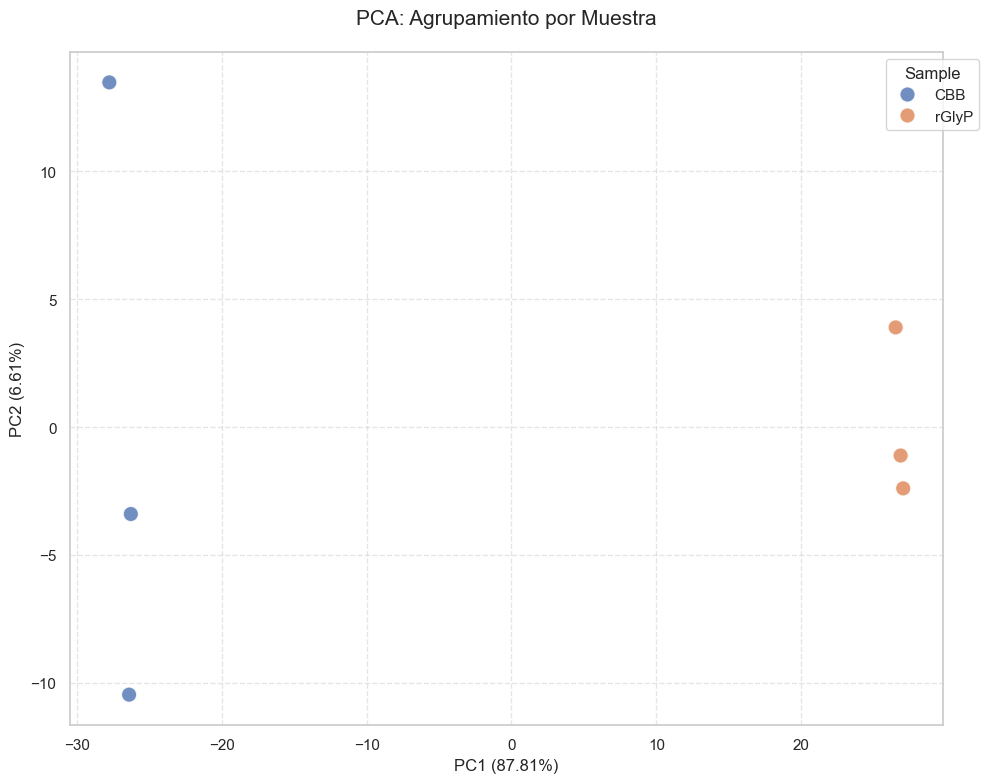

In [15]:
plot('PC1', 'PC2', df_pca_coords.reset_index(), 'PCA: Agrupamiento por Muestra', hue='Sample', style=None,  paleta='deep', file='figuras/05_pca_por_muestra.png')


In [16]:
import numpy as np

In [17]:
X_prot = pd.DataFrame(np.concat((data_protein[cepa_CBB].to_numpy(), data_protein[cepa_rGlyP].to_numpy())))

In [18]:
X_prot

,0,1,2
0,26.392931,26.320032,26.349343
1,21.483608,21.568191,21.640735
2,27.211578,27.108774,27.220774
3,32.618989,32.412991,32.299652
4,27.982094,28.089317,28.277010
...,...,...,...
5833,24.817430,24.982458,24.917217
5834,33.212505,33.180884,33.246544
5835,23.168801,23.044661,23.121074
5836,29.645631,29.482916,29.616149


In [19]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_prot.to_numpy())

df_pca_coords = pd.DataFrame(
    data = pca_result, 
    columns = ['PC1', 'PC2'],
    index = list(data_protein.index)+list(data_protein.index)
)

var_exp = pca.explained_variance_ratio_*100

df_pca_coords['Cepa'] = (['CBB'] * data_protein[cepa_CBB].shape[0]) + (['rGlyP'] * data_protein[cepa_rGlyP].shape[0])
df_pca_coords

,PC1,PC2,Cepa
O07451,2.787013,0.032033,CBB
O30338,-5.509199,-0.126618,CBB
O87816,4.218327,0.008497,CBB
P14611,13.334413,0.232692,CBB
P14697,5.839344,-0.198902,CBB
...,...,...,...
Q7WXU0,0.278185,-0.101879,rGlyP
Q83WS0,14.667553,-0.007876,rGlyP
Q8KLU8,-2.829206,0.037955,rGlyP
Q9X6U2,8.377321,0.047848,rGlyP


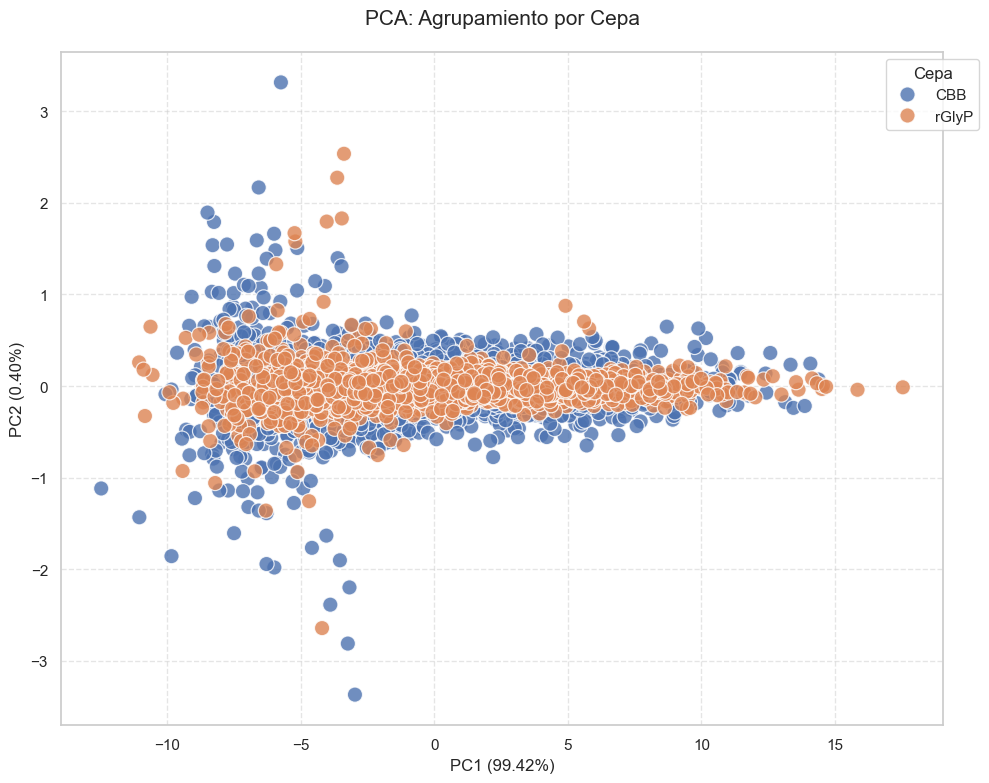

In [20]:
plot('PC1', 'PC2', df_pca_coords.reset_index(), 'PCA: Agrupamiento por Cepa', hue='Cepa', style=None,  paleta='deep', file='figuras/05_pca_por_cepa.png')
